In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path

from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    DeseqCPMSelector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from itertools import product


In [3]:
RANDOM_STATE = 42
RNA_COUNT_FILTER = 15
RNA_COUNT_FILTER_MIN_SAMPLES = 5
DESEQ_PVALUE = 0.1
DESEQ_MIN_FEATURES = 20

# Which RFS horizon (in years) to evaluate: 1 or 2.
RFS_YEAR = 2

# Read data

In [4]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

rna_data = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

In [5]:
columns = rna_data["Gene Symbol"]
rna_data = rna_data.T.iloc[2:, :]
rna_data.columns = columns.values

# Drop columns with NaN gene symbols and deduplicate gene names
rna_data = rna_data.loc[:, ~pd.isnull(rna_data.columns)]
rna_data = rna_data.loc[:, ~rna_data.columns.duplicated()]

# Convert expression values to numeric, make SID an integer column
rna_data = rna_data.apply(pd.to_numeric, errors="coerce")
rna_data.index = rna_data.index.astype(int)
rna_data = rna_data.rename_axis("SID").reset_index()

print(f"RNA data shape (patients × genes): {rna_data.shape}")
rna_data.head()

RNA data shape (patients × genes): (60, 50987)


,SID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
0,39,0,0,0,0,0,0,245,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,150,0,153,0,0,0,828,63,0,...,0,0,0,0,0,0,0,0,0,0
3,33,139,0,0,0,0,0,3206,0,224,...,0,0,0,0,0,1,0,3,0,0
4,132,0,0,0,0,37,2,985,0,236,...,0,0,0,0,0,1,0,0,0,0


# RFS column

In [6]:
def rfs(rfs_central: float, rfs_central_event: float, year: int) -> int | None:
    if rfs_central_event == 1:
        if rfs_central < year:
            return 1
        else:
            return 0
    else:
        if rfs_central < year:
            return None
        else:
            return 0


clinical_data["rfs_1year"] = clinical_data.apply(
    lambda row: rfs(row["RFS_central"], row["RFS_central_event"], 1 * 12), axis=1
)
clinical_data["rfs_2year"] = clinical_data.apply(
    lambda row: rfs(row["RFS_central"], row["RFS_central_event"], 2 * 12), axis=1
)
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].head(10)

/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_15195/1519945546.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clinical_data["rfs_1year"] = clinical_data.apply(
/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_15195/1519945546.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clinical_data["rfs_2year"] = clinical_data.apply(


,RFS_central,RFS_central_event,rfs_1year,rfs_2year
0,31.791781,0.0,0.0,0.0
1,30.279452,1.0,0.0,0.0
2,40.865753,1.0,0.0,0.0
3,14.301370,1.0,0.0,1.0
4,24.756164,1.0,0.0,0.0
5,9.600000,1.0,1.0,1.0
6,8.054795,1.0,1.0,1.0
7,6.936986,1.0,1.0,1.0
8,49.643836,1.0,0.0,0.0
9,11.441096,1.0,1.0,1.0


In [7]:
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].tail(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
59,52.734247,0.0,0.0,0.0
60,63.813699,1.0,0.0,0.0
61,75.879452,0.0,0.0,0.0
62,2.367123,0.0,NaN,NaN
63,7.791781,1.0,1.0,1.0
64,5.983562,1.0,1.0,1.0
65,5.786301,1.0,1.0,1.0
66,132.526027,1.0,0.0,0.0
67,27.320548,1.0,0.0,0.0
68,97.347945,0.0,0.0,0.0


In [8]:
print(clinical_data["rfs_1year"].value_counts(dropna=False))
print(clinical_data["rfs_2year"].value_counts(dropna=False))

rfs_1year
0.0    43
1.0    21
NaN     5
Name: count, dtype: int64
rfs_2year
0.0    34
1.0    28
NaN     7
Name: count, dtype: int64


In [9]:
rna_count = rna_data.drop(columns=["SID"])
rna_count.index = rna_data["SID"]
print("Before filtering:", rna_count.shape[1])
rna_count_flt = rna_count.loc[
    :, (rna_count >= RNA_COUNT_FILTER).sum(axis=0) >= RNA_COUNT_FILTER_MIN_SAMPLES
]
print("After filtering:", rna_count_flt.shape[1])
rna_count_flt.head()

Before filtering: 50986
After filtering: 27991


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC087564.1,FO393400.1,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
66,150,0,153,0,0,0,828,63,0,82,...,0,0,123,0,0,0,0,0,0,0
33,139,0,0,0,0,0,3206,0,224,0,...,98,0,15,0,0,0,64,0,0,3
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
rna_rfs = rna_count_flt.merge(
    clinical_data[["SID", "rfs_1year", "rfs_2year"]], on="SID"
)
rna_rfs = rna_rfs.set_index("SID")
rna_rfs.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3,rfs_1year,rfs_2year
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0.0,1.0
66,150,0,153,0,0,0,828,63,0,82,...,123,0,0,0,0,0,0,0,NaN,NaN
33,139,0,0,0,0,0,3206,0,224,0,...,15,0,0,0,64,0,0,3,0.0,1.0
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,NaN,NaN


# CV experiments

In [11]:
selector = DeseqCPMSelector(pvalue=DESEQ_PVALUE, min_features=DESEQ_MIN_FEATURES)

In [12]:
X = rna_rfs.drop(columns=["rfs_1year", "rfs_2year"])
x_columns = {col: DataType.CONTINUOUS for col in X}

y = rna_rfs[f"rfs_{RFS_YEAR}year"]
EXPERIMENT_LABEL = f"RFS {RFS_YEAR} year - RNA-seq"

## RFS (horizon set by `RFS_YEAR`)

### Logistic regression

In [13]:
MODELS_LR: dict[str, object] = {}
for c in [0.001, 0.01, 0.1, 1]:
    MODELS_LR[f"LR_C={c}"] = LogisticRegression(
        solver="liblinear", l1_ratio=1.0, C=c, max_iter=1000, random_state=RANDOM_STATE
    )
records_lr, fold_records_lr = run_cv_experiment(
    X,
    y,
    x_columns,
    EXPERIMENT_LABEL,
    feature_selector=selector,
    selector_first=True,
    models=MODELS_LR,
)

[RFS 2 year - RNA-seq]  n=54  positives=25  features=27991
Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.13 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...


... done in 1.10 seconds.

Fitting LFCs...


...

... done in 0.40 seconds.

Fitting LFCs...


... done in 0.86 seconds.



Running Wald tests...


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       195.711751       -1.423443  1.513010 -0.940802  0.346806   
TNMD          15.175317        1.989439  2.058678  0.966367  0.333860   
DPM1         184.409332       -0.624720  1.424522 -0.438547  0.660990   
SCYL3        156.529437       -0.016349  1.310231 -0.012478  0.990044   
C1orf112      96.085442       -0.561813  1.454457 -0.386270  0.699297   
...                 ...             ...       ...       ...       ...   
BX571818.1     3.660581       -3.654562  2.305247 -1.585323  0.112893   
AC093827.5     1.874222       -1.476398  2.494240 -0.591923  0.553902   
AC139491.7     1.703708       -1.028280  2.770893 -0.371101  0.710563   
AC135068.11    3.205929        5.059809  2.928916  1.727537  0.084071   
AL356417.3     2.840619       -0.660263  1.484084 -0.444896  0.656395   

                 padj  
TSPAN6       0.999691  
TNMD         0.99969

... done in 0.41 seconds.



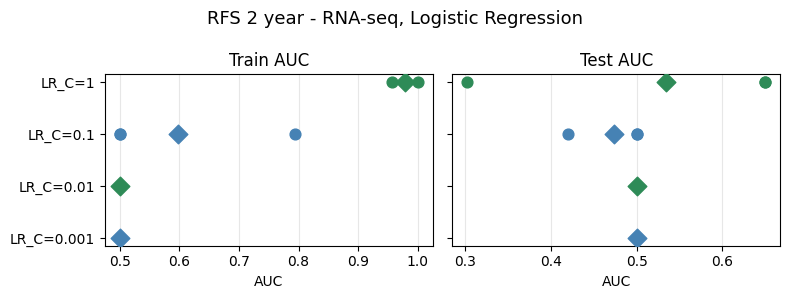

In [14]:
plot_cv_results(fold_records_lr, title=f"{EXPERIMENT_LABEL}, Logistic Regression")

### Random Forest

In [15]:
MODELS_RF: dict[str, object] = {}
for max_depth, min_samples_leaf in product([2, 4], [5, 10, 15]):
    MODELS_RF[f"RF_max_depth={max_depth}_min_samples_leaf={min_samples_leaf}"] = (
        RandomForestClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )
    )
records_rf, fold_records_rf = run_cv_experiment(
    X,
    y,
    x_columns,
    EXPERIMENT_LABEL,
    feature_selector=selector,
    selector_first=True,
    models=MODELS_RF,
)

[RFS 2 year - RNA-seq]  n=54  positives=25  features=27991
Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.15 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.



Fitting MAP dispersions...


...

... done in 0.42 seconds.

Fitting LFCs...


... done in 0.82 seconds.



Running Wald tests...


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       195.711751       -1.423443  1.513010 -0.940802  0.346806   
TNMD          15.175317        1.989439  2.058678  0.966367  0.333860   
DPM1         184.409332       -0.624720  1.424522 -0.438547  0.660990   
SCYL3        156.529437       -0.016349  1.310231 -0.012478  0.990044   
C1orf112      96.085442       -0.561813  1.454457 -0.386270  0.699297   
...                 ...             ...       ...       ...       ...   
BX571818.1     3.660581       -3.654562  2.305247 -1.585323  0.112893   
AC093827.5     1.874222       -1.476398  2.494240 -0.591923  0.553902   
AC139491.7     1.703708       -1.028280  2.770893 -0.371101  0.710563   
AC135068.11    3.205929        5.059809  2.928916  1.727537  0.084071   
AL356417.3     2.840619       -0.660263  1.484084 -0.444896  0.656395   

                 padj  
TSPAN6       0.999691  
TNMD         0.99969

... done in 0.45 seconds.



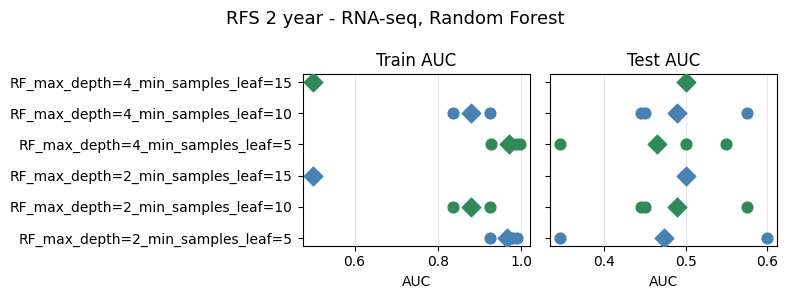

In [16]:
plot_cv_results(fold_records_rf, title=f"{EXPERIMENT_LABEL}, Random Forest")